In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
run_name = "ch12_sft-full"

data_dir = Path("data") / "ch12" / "sft-full"
tsv = data_dir / "training.tsv"

In [3]:
df = pd.read_csv(tsv, sep='\t')
df = df.sort_values(by='step', ascending=True)
df = df.drop_duplicates(subset=['step', 'split'], keep='last')

train_df = df.loc[df['split'] == 'train', :]
eval_df = df.loc[df['split'] == 'eval', :]

df.nsmallest(10, 'loss')

,step,epoch,split,loss,learning_rate,created_at
48,2000,44,train,4.106,0.000070,2025-10-20T12:47:52%:z
47,1950,43,train,4.140,0.000072,2025-10-20T12:46:28%:z
46,1900,42,train,4.153,0.000073,2025-10-20T12:45:06%:z
43,1800,40,train,4.191,0.000076,2025-10-19T08:04:18%:z
42,1750,39,train,4.213,0.000077,2025-10-19T08:02:55%:z
41,1700,37,train,4.239,0.000079,2025-10-19T08:01:33%:z
45,1850,41,train,4.241,0.000075,2025-10-20T12:43:45%:z
38,1600,35,train,4.289,0.000081,2025-10-19T01:42:55%:z
37,1550,34,train,4.308,0.000083,2025-10-19T01:41:27%:z
40,1650,36,train,4.335,0.000080,2025-10-19T08:00:12%:z


In [4]:
train_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
37,1550,34,train,4.308,0.000083,2025-10-19T01:41:27%:z
38,1600,35,train,4.289,0.000081,2025-10-19T01:42:55%:z
40,1650,36,train,4.335,0.000080,2025-10-19T08:00:12%:z
41,1700,37,train,4.239,0.000079,2025-10-19T08:01:33%:z
42,1750,39,train,4.213,0.000077,2025-10-19T08:02:55%:z
43,1800,40,train,4.191,0.000076,2025-10-19T08:04:18%:z
45,1850,41,train,4.241,0.000075,2025-10-20T12:43:45%:z
46,1900,42,train,4.153,0.000073,2025-10-20T12:45:06%:z
47,1950,43,train,4.140,0.000072,2025-10-20T12:46:28%:z
48,2000,44,train,4.106,0.000070,2025-10-20T12:47:52%:z


In [5]:
eval_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
4,200,5,eval,6.808,NaN,2025-10-19T01:00:17%:z
9,400,9,eval,6.680,NaN,2025-10-19T01:06:12%:z
14,600,14,eval,6.678,NaN,2025-10-19T01:12:10%:z
19,800,18,eval,6.733,NaN,2025-10-19T01:19:16%:z
24,1000,22,eval,6.799,NaN,2025-10-19T01:25:10%:z
29,1200,27,eval,6.886,NaN,2025-10-19T01:31:05%:z
34,1400,31,eval,6.976,NaN,2025-10-19T01:37:02%:z
39,1600,35,eval,7.035,NaN,2025-10-19T01:42:57%:z
44,1800,40,eval,7.108,NaN,2025-10-19T08:04:20%:z
49,2000,44,eval,7.170,NaN,2025-10-20T12:47:53%:z


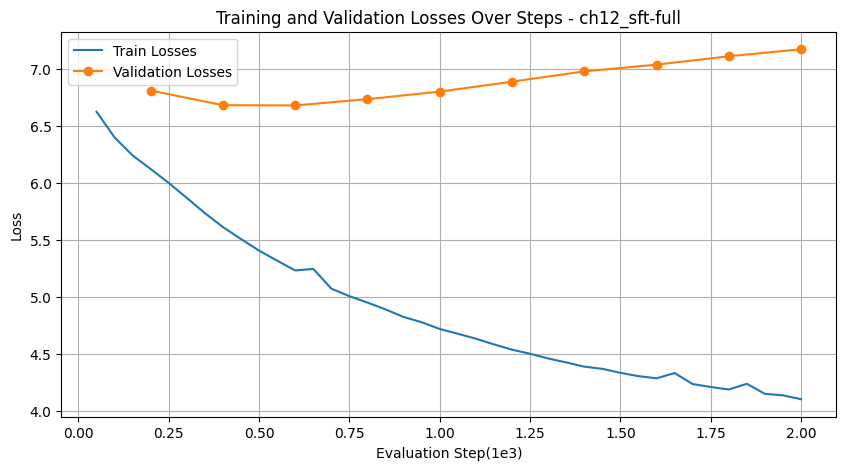

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['loss'], label="Train Losses")
plt.plot(eval_df['step']/1e3, eval_df['loss'], label="Validation Losses", marker='o')
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title(f"Training and Validation Losses Over Steps - {run_name}")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(data_dir / "training.pdf")

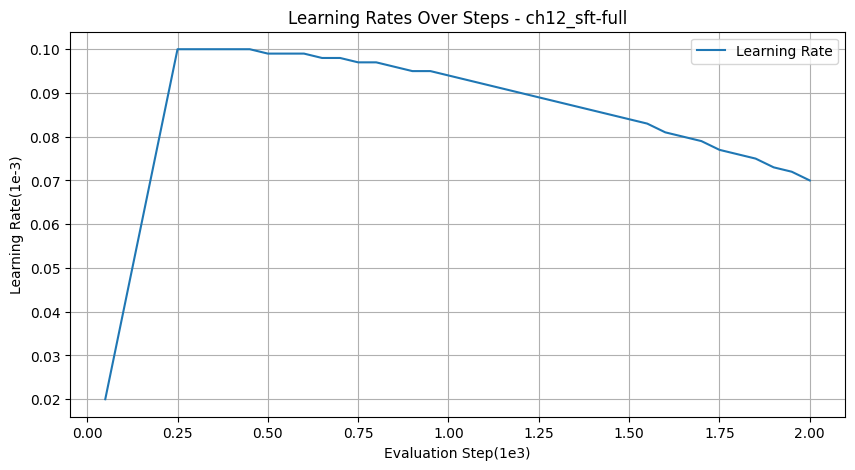

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['learning_rate']*1e3, label="Learning Rate")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Learning Rate(1e-3)")
plt.title(f"Learning Rates Over Steps - {run_name}")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(data_dir / "learning_rate.pdf")